In [531]:
# import pytorch
import torch
import torch.nn as nn

In [532]:
x = torch.randn(2, 3)
print(x)

tensor([[ 0.3831, -0.5108, -0.7290],
        [ 1.2751,  1.7646,  0.1693]])


In [533]:
x = torch.tensor([[99, 99, 99]], dtype=torch.float32)
print(x.shape)

torch.Size([1, 3])


In [534]:
z = x + x
print(z)

tensor([[198., 198., 198.]])


In [535]:
x.add(x)

tensor([[198., 198., 198.]])

In [536]:
print(x)

tensor([[99., 99., 99.]])


In [537]:
x.add_(x) # In-place addition
print(x)

tensor([[198., 198., 198.]])


In [538]:
y = torch.rand(1, 3).flatten()
y

tensor([0.5072, 0.3947, 0.9699])

In [539]:
z = torch.randint(0, 10, (1,), requires_grad=True, dtype=torch.float16)
print(z)

tensor([7.], dtype=torch.float16, requires_grad=True)


In [540]:
z = torch.randint(0, 10, (1, 9), dtype=torch.float16).clone().detach().requires_grad_()
loss = z.sum()
print("z:", z)
loss.backward()
print("z.grad:", z.grad)


z: tensor([[5., 6., 8., 6., 3., 1., 6., 9., 3.]], dtype=torch.float16,
       requires_grad=True)
z.grad: tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1.]], dtype=torch.float16)


In [541]:
x = torch.tensor([0.5,2.1,3.2], dtype=torch.float32, requires_grad=True)
z = torch.tensor([0.1,1.0,0.001], dtype=torch.float32)
x.backward(z) # This computes the gradient of x with respect to z
print(x.grad)

tensor([0.1000, 1.0000, 0.0010])


In [542]:
# This code snippet demonstrates basic tensor operations in PyTorch, including creation, manipulation, and gradient computation.
# It covers tensor addition, in-place operations, random tensor generation, and gradient calculation using the backward method.
# The code also illustrates how to set up tensors with specific data types and gradient requirements.
# The final output will show the gradients computed for the tensor `x` based on the operations performed.
X = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32, requires_grad=True)
print(X)


tensor([[1., 2.],
        [3., 4.]], requires_grad=True)


In [543]:
Y = torch.tensor([[5, 6], [7, 8]], dtype=torch.float32,  requires_grad=True)
Z = X + Y
print(Z)


tensor([[ 6.,  8.],
        [10., 12.]], grad_fn=<AddBackward0>)


In [544]:
# The above code initializes two tensors `X` and `Y`, performs element-wise addition, and prints the result.
# It demonstrates basic tensor operations in PyTorch, including tensor creation and arithmetic operations.
# The final output will show the result of the addition of tensors `X` and `Y`.
Z.backward(Y)  # This computes the gradient of Z with respect to X and Y
print(X.grad)  # Prints the gradient of X

tensor([[5., 6.],
        [7., 8.]])


# Deep Nueral Network (Basic)

In [545]:
# dataset for training leaf length with age
# iris dataset 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
import torch

In [546]:
data = load_iris()
x = data.data[:, 0]
y = data.data[:, 1]

In [547]:
# x and y as dummy dataset
x = torch.tensor(x, dtype = torch.float32).reshape(-1,1) # Input feature
y = torch.tensor(y, dtype = torch.float32).reshape(-1,1) # Target variable
# Initialize weights and bias
w = torch.randn((1,3), requires_grad=True)  # Weight
b = torch.tensor(0.1, requires_grad=True)  # Bias

# Back Propagation

```python

In [548]:
# complete training looop

print("w:", w)
print("b:", b)
learning_rate = 0.1
epochs = 12
for epoch in range(epochs):  # Example: 100 epochs
    # forward pass
    y_pred = x @ w + b
    loss = (y_pred - y).pow(2).sum()  # Mean Squared Error

    # backward pass
    loss.backward()  # Compute gradients

    # update weights
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad        



w: tensor([[-0.0737,  1.0882,  0.4458]], requires_grad=True)
b: tensor(0.1000, requires_grad=True)


In [549]:
print("w:", w)
print("b:", b)

w: tensor([[-9.6429e+35,  9.5811e+35, -1.0478e+35]], requires_grad=True)
b: tensor(-1.8646e+34, requires_grad=True)


In [550]:
i = torch.tensor([11.2], dtype=torch.float32)  # Example input
i * w + b
# This code snippet demonstrates a basic implementation of a deep neural network using PyTorc

tensor([[-1.0819e+37,  1.0712e+37, -1.1922e+36]], grad_fn=<AddBackward0>)

# Gradient Descent

## Linear Regression with PyTorch

In [551]:
import numpy as np
x = np.array([1, 2, 3, 4, 5])
y = np.array([5, 10, 15, 20, 25])
w = 0.01
b = 0.01
def forward(x, w, b):
    return x * w + b
def gradient(x, y, w, b, error):
    return (2/ len(x)) * np.dot(x.T, (error)), (2 / len(x)) * np.sum(error)
                                
def backward(x, y, w, b):
    y_pred = forward(x, w, b)
    error = y_pred - y
    grad_w, grad_b = gradient(x, y, w, b, error)
    return grad_w, grad_b

def loss(y_pred, y):
    return np.mean((y_pred - y) ** 2)  # Mean Squared Error
def update(w, b, grad_w, grad_b, learning_rate):
    w -= learning_rate * grad_w
    b -= learning_rate * grad_b
    return w, b


In [552]:
lr = 0.035
lossi = 1000
epochs = 100
for i in range(epochs):
    y_pred = forward(x, w, b)
    lossi = loss(y_pred, y)
    grad_w, grad_b = backward(x, y, w, b)
    w, b = update(w, b, grad_w, grad_b, lr)
    grad_b, grad_w = None, None  # Reset gradients to avoid accumulation
    if i % 11 == 0:  # Print every 10 epochs
        print(f"Epoch {i}, Loss: {lossi}, w: {w}, b: {b}")

Epoch 0, Loss: 273.6018, w: 3.8502000000000005, b: 1.0572000000000001
Epoch 11, Loss: 0.23417665823648784, w: 4.689544004027669, b: 1.1208446406827095
Epoch 22, Loss: 0.18022194581278253, w: 4.727647050596297, b: 0.9832805644702476
Epoch 33, Loss: 0.13869849368055148, w: 4.761073611898107, b: 0.8626000719802476
Epoch 44, Loss: 0.10674211768436859, w: 4.790397647404217, b: 0.7567309993371104
Epoch 55, Loss: 0.08214854671735519, w: 4.81612267040612, b: 0.6638555037946418
Epoch 66, Loss: 0.06322137759837342, w: 4.838690396744829, b: 0.582378851011113
Epoch 77, Loss: 0.04865506141195945, w: 4.85848832936713, b: 0.5109020323946012
Epoch 88, Loss: 0.03744485000058698, w: 4.875856412010214, b: 0.4481977431902885
Epoch 99, Loss: 0.028817490942921475, w: 4.891092866262876, b: 0.3931893088374225


In [553]:
print(f"Prediction before training: {forward(x, 0.1, 0.1)}")
print(f"Prediction after training: {forward(x, w, b)}")
print("Original y:", y)

Prediction before training: [0.2 0.3 0.4 0.5 0.6]
Prediction after training: [ 5.28428218 10.17537504 15.06646791 19.95756077 24.84865364]
Original y: [ 5 10 15 20 25]


In [554]:
# using pytorch to
# design the model
# training loop:
## forward pass
## backward pass
## update weights

In [555]:
x = torch.tensor(x, dtype = torch.float32).reshape(-1,1) # Input feature
y = torch.tensor(y, dtype = torch.float32).reshape(-1,1) #
# Target variable
w = torch.randn((1,1), requires_grad=True)  # Weight
b = torch.tensor(0.1, requires_grad=True)  # Bias
def forward(x, w, b):
    return x * w + b
def loss(y_pred, y):
    #return torch.mean((y_pred - y) ** 2)  # Mean Squared Error
    # mse in pytorch
    return torch.nn.functional.mse_loss(y_pred, y)  # Mean Squared Error

def gradient(x, y, w, b, error):

    grad_w = (2 / len(x)) * torch.matmul(x.T, error)
    grad_b = (2 / len(x)) * torch.sum(error)
    return grad_w, grad_b
def backward(x, y, w, b):
    y_pred = forward(x, w, b)
    error = y_pred - y
    grad_w, grad_b = gradient(x, y, w, b, error)
    return grad_w, grad_b
def update(w, b, learning_rate):
    with torch.no_grad():
        w -= learning_rate * w.grad
        b -= learning_rate * b.grad
        #b.grad.zero_()  # Reset gradients to avoid accumulation
        w.grad.zero_()  
    return w, b
# loop for 100 epochs and 0.035 learning rate
lr = 0.01
for i in range(100):
    y_pred = forward(x, w, b)
    lossi = loss(y_pred, y)
    #grad_w, grad_b = backward(x, y, w, b)
    lossi.backward()  # Compute gradients
    
    w, b = update(w, b, lr)
    if i % 11 == 0:  # Print every 10 epochs
        print(f"Epoch {i}, Loss: {lossi.item()}, w: {w.item()}, b: {b.item()}")

Epoch 0, Loss: 270.52227783203125, w: 1.1046212911605835, b: 0.3971829414367676
Epoch 11, Loss: 17.33402442932129, w: 3.1776974201202393, b: 9.16029167175293
Epoch 22, Loss: 26.342239379882812, w: 1.9172675609588623, b: 11.823575019836426
Epoch 33, Loss: 15.744532585144043, w: 2.2966175079345703, b: 8.388443946838379
Epoch 44, Loss: 5.968021392822266, w: 3.440424680709839, b: 3.991161823272705
Epoch 55, Loss: 1.3981268405914307, w: 4.408987522125244, b: 1.0677119493484497
Epoch 66, Loss: 0.21472196280956268, w: 4.931220531463623, b: -0.20718462765216827
Epoch 77, Loss: 0.04969707876443863, w: 5.106202602386475, b: -0.4723428785800934
Epoch 88, Loss: 0.025500591844320297, w: 5.108675003051758, b: -0.3403163254261017
Epoch 99, Loss: 0.009664630517363548, w: 5.0619049072265625, b: -0.15472407639026642


In [556]:
print(f"prediction before training: {forward(x, 0.1, 0.1)}")
print(f"Prediction after training: {forward(x, w, b)}")
print("Original y:", y)

prediction before training: tensor([[0.2000],
        [0.3000],
        [0.4000],
        [0.5000],
        [0.6000]])
Prediction after training: tensor([[ 4.9072],
        [ 9.9691],
        [15.0310],
        [20.0929],
        [25.1548]], grad_fn=<AddBackward0>)
Original y: tensor([[ 5.],
        [10.],
        [15.],
        [20.],
        [25.]])


## Logistic Regression with PyTorch using ANN

In [557]:
# designing an ANN for logistic regression
import torch
import torch.nn as nn
import torch.optim as optim
class LogisticRegressionModel(nn.Module):
    def __init__(self, input_size):
        super(LogisticRegressionModel, self).__init__()
        self.linear = nn.Linear(input_size, 1)  # Single output for binary classification

    def forward(self, x):
        
        return torch.sigmoid(self.linear(x))  # Sigmoid activation for binary classification
# Example usage
input_size = 1  # Number of input features
model = LogisticRegressionModel(input_size)
# Define loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.SGD(model.parameters(), lr=0.01)  # Stochastic Gradient


In [558]:
# Descent optimizer
# Dummy dataset
x = torch.tensor([[9.0], [2.0], [3.0], [0.5], [5.0]], dtype=torch.float32)  # Input features
y = torch.tensor([[0.0], [0.0], [1.0], [0.0], [1.0]], dtype=torch.float32)  # Target labels
# Training loop
num_epochs = 100
for epoch in range(num_epochs):
    # Forward pass
    outputs = model(x)
    loss = criterion(outputs, y)  # Compute loss
    # Backward pass and optimization
    optimizer.zero_grad()  # Zero the gradients
    loss.backward()  # Backpropagation
    optimizer.step()  # Update weights
    if (epoch+1) % 10 == 0:  # Print every 10 epochs
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/100], Loss: 0.7734
Epoch [20/100], Loss: 0.7035
Epoch [30/100], Loss: 0.6816
Epoch [40/100], Loss: 0.6753
Epoch [50/100], Loss: 0.6736
Epoch [60/100], Loss: 0.6730
Epoch [70/100], Loss: 0.6729
Epoch [80/100], Loss: 0.6728
Epoch [90/100], Loss: 0.6728
Epoch [100/100], Loss: 0.6728


In [559]:

# Example prediction
with torch.no_grad():
    test_input = torch.tensor([[6.0]], dtype=torch.float32)  # New input for prediction
    predicted = model(test_input)
    print(f'Predicted probability for input {test_input.item()}: {predicted.item():.4f}')
# This code implements a simple logistic regression model using PyTorch.
# It defines a neural network with a single linear layer and a sigmoid activation function.

Predicted probability for input 6.0: 0.4108


In [560]:
torch.tensor([[6.0]], dtype=torch.float32)

tensor([[6.]])

## Wine Dataset with PyTorch

In [561]:
import torch   
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
import numpy as np  
import pandas as pd
from sklearn.model_selection import train_test_split


In [562]:
class LettuceDataset(Dataset):
    def __init__(self, df):
        self.data = df.copy()
        features = self.data.iloc[:, :-1].apply(pd.to_numeric, errors='coerce').fillna(0).values
        self.x = torch.tensor(features, dtype=torch.float32)  # Features
        self.y = torch.tensor(self.data.iloc[:, -1].values, dtype=torch.long)  # Labels

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.x[idx], self.y[idx]

In [563]:
df = pd.read_csv('data/vine_quality.csv', delimiter=',')
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


In [564]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['quality'] = le.fit_transform(df['quality'])  # modifies labels in-place

# Check new labels:
print(sorted(df['quality'].unique()))

[0, 1, 2, 3, 4, 5]


In [565]:
dff = df.drop(df.columns[-1], axis=1) 
dataset = LettuceDataset(dff) 
x = dataset.x
y = dataset.y
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [566]:
input_size = x.shape[1]  # Number of input features columns


In [567]:
# classification nn.
import torch.nn as nn
import torch.nn.functional as F

class ClassificationNN(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ClassificationNN, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.bn1 = nn.BatchNorm1d(hidden_dim)
        
        self.fc2 = nn.Linear(hidden_dim, hidden_dim * 2)
        self.bn2 = nn.BatchNorm1d(hidden_dim * 2)

        self.fc3 = nn.Linear(hidden_dim * 2, hidden_dim // 2)
        self.fc4 = nn.Linear(hidden_dim // 2, output_dim)

        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(F.relu(self.bn2(self.fc2(x))))
        x = F.relu(self.fc3(x))
        x = self.fc4(x)  # No softmax for CrossEntropyLoss
        return x


# Example usage:
# input_dim = input_size (already defined)
# hidden_dim = 32 (example)
# output_dim = number of classes, e.g., 3 for 3-class classification
# model_cls = ClassificationNN(input_size, 32, 3)

In [568]:
output_size = df['quality'].nunique()  # Number of unique classes in the target variable
hidden_dim = 32  # Example hidden layer size
model = ClassificationNN(input_size, hidden_dim, output_size)  # Linear model for regression


In [569]:
df['quality'].unique()

array([2, 3, 4, 1, 5, 0], dtype=int64)

In [570]:
# from sklearn.utils.class_weight import compute_class_weight
# class_weights = compute_class_weight('balanced', classes=np.unique(df['quality']), y=df['quality'])
# class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32)
criterian = nn.CrossEntropyLoss()  # Cross-Entropy Loss for multi-class classification
learning_rate = 0.01
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

In [571]:
list(model.parameters())

[Parameter containing:
 tensor([[ 0.0598,  0.1081,  0.1265, -0.0082, -0.1063, -0.1160, -0.0562, -0.1431,
           0.2012,  0.2668,  0.1485],
         [ 0.1065,  0.0680, -0.1442,  0.0025, -0.0048, -0.1677,  0.1293, -0.0342,
           0.2144, -0.1785,  0.2364],
         [-0.0836,  0.0287,  0.2197,  0.1931, -0.0537,  0.0434, -0.0291,  0.0512,
           0.0529,  0.0589,  0.0509],
         [ 0.2973,  0.0074, -0.0622,  0.0330,  0.0913, -0.1449,  0.1321,  0.2260,
          -0.1008,  0.2783,  0.2010],
         [-0.0209,  0.1111, -0.2805, -0.1998, -0.0364,  0.2412, -0.1030, -0.2454,
           0.0552,  0.0203, -0.0270],
         [ 0.2022, -0.1836,  0.1192, -0.2816, -0.1826, -0.1742,  0.0731, -0.1377,
          -0.1023, -0.0293, -0.1145],
         [ 0.2049, -0.1139, -0.0994, -0.1264, -0.1027,  0.2455,  0.0456,  0.2876,
           0.0170,  0.1424, -0.2631],
         [-0.0311,  0.2058,  0.2150,  0.0693,  0.2114, -0.0145, -0.1257,  0.0112,
          -0.0395,  0.1474,  0.0417],
         [-0.1346

In [572]:
num_epochs = 500
for epoch in range(num_epochs):
    # model
    y_hat = model(X_train)

    # loss
    loss = criterian(y_hat, y_train)

    # backpropagation
    loss.backward()

    #optimizer
    optimizer.step()
    optimizer.zero_grad()

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')


Epoch [10/500], Loss: 1.6237
Epoch [20/500], Loss: 1.4686
Epoch [30/500], Loss: 1.3346
Epoch [40/500], Loss: 1.2357
Epoch [50/500], Loss: 1.1862
Epoch [60/500], Loss: 1.1696
Epoch [70/500], Loss: 1.1426
Epoch [80/500], Loss: 1.1226
Epoch [90/500], Loss: 1.1114
Epoch [100/500], Loss: 1.0952
Epoch [110/500], Loss: 1.0608
Epoch [120/500], Loss: 1.0473
Epoch [130/500], Loss: 1.0231
Epoch [140/500], Loss: 1.0252
Epoch [150/500], Loss: 0.9935
Epoch [160/500], Loss: 1.0023
Epoch [170/500], Loss: 0.9665
Epoch [180/500], Loss: 0.9662
Epoch [190/500], Loss: 0.9446
Epoch [200/500], Loss: 0.9566
Epoch [210/500], Loss: 0.9473
Epoch [220/500], Loss: 0.9341
Epoch [230/500], Loss: 0.9492
Epoch [240/500], Loss: 0.9418
Epoch [250/500], Loss: 0.9148
Epoch [260/500], Loss: 0.9197
Epoch [270/500], Loss: 0.9017
Epoch [280/500], Loss: 0.9030
Epoch [290/500], Loss: 0.8985
Epoch [300/500], Loss: 0.8907
Epoch [310/500], Loss: 0.8842
Epoch [320/500], Loss: 0.8826
Epoch [330/500], Loss: 0.8777
Epoch [340/500], Lo

In [573]:
# evaluate
with torch.no_grad():
    y_pred = model(X_test)
    _, predicted = torch.max(y_pred, 1)  # Get the index of the max log-probability
    accuracy = (predicted == y_test).sum().item() / y_test.size(0)
    print(f'Accuracy: {accuracy * 100:.2f}%')

Accuracy: 61.14%


Text(0.5, 1.0, 'Confusion Matrix')

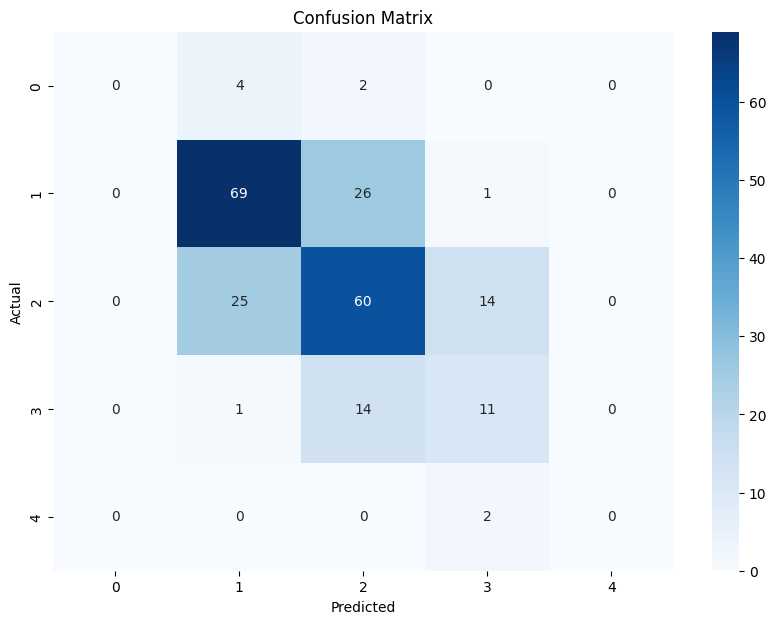

In [574]:
# confusion matrix
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
cm = confusion_matrix(y_test.numpy(), predicted.numpy())
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
# This code implements a classification neural network using PyTorch.

In [575]:
# report classification metrics
from sklearn.metrics import classification_report
class_labels = sorted(df['quality'].unique())  # e.g., [0, 1, 2, 3, 4, 5]

# Generate report
report = classification_report(
    y_test.numpy(),
    predicted.numpy(),
    labels=class_labels,
    target_names=[str(c) for c in class_labels]
)

print(report)


              precision    recall  f1-score   support

           0       0.00      0.00      0.00         0
           1       0.00      0.00      0.00         6
           2       0.70      0.72      0.71        96
           3       0.59      0.61      0.60        99
           4       0.39      0.42      0.41        26
           5       0.00      0.00      0.00         2

   micro avg       0.61      0.61      0.61       229
   macro avg       0.28      0.29      0.29       229
weighted avg       0.59      0.61      0.60       229



d:\Conda\envs\doraenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Conda\envs\doraenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Conda\envs\doraenv\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
d:\Conda\envs\doraenv\lib\site-packages\sklearn\metrics\_classification.